In [227]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score
)
from sklearn.pipeline import Pipeline
import joblib

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"

# read CSV from URL
df = pd.read_csv(url)

# quick checks
print("Rows, columns:", df.shape)
df.info()
df.head()

Rows, columns: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [228]:
# ajuste de columnas
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0}).astype('Int64')
print(df['Sex'].value_counts(dropna=False))

mean_age = df['Age'].mean()                       # skips NaN by default
df.fillna({'Age': mean_age}, inplace=True)

# if you already built X and want to fill there instead:
# X['Age'].fillna(X['Age'].mean(), inplace=True)

# verify
print("Missing ages after fill:", df['Age'].isna().sum())
print("Mean age used:", mean_age)

Sex
1    577
0    314
Name: count, dtype: Int64
Missing ages after fill: 0
Mean age used: 29.69911764705882


In [229]:
women = df.loc[df.Sex == 0]["Survived"]
rate_women = sum(women)/len(women)

print("% de mujeres que sobrevivieron:", rate_women * 100)

men = df.loc[df.Sex == 1]["Survived"]
rate_men = sum(men)/len(men)

print("% de hombres que sobrevivieron:", rate_men * 100)

% de mujeres que sobrevivieron: 74.20382165605095
% de hombres que sobrevivieron: 18.890814558058924


In [230]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Fare']
X = pd.get_dummies(df[features], drop_first=True)
y = df['Survived']

print("Shape X:", X.shape)           # (n_muestras, n_features)
print("Clases:", pd.Series(y).value_counts())
print(X.describe().T.head(10))       # primeras 10 features resumidas
print("Valores faltantes (por columna):\n", X.isna().sum().sort_values(ascending=False).head())

Shape X: (891, 8)
Clases: Survived
0    549
1    342
Name: count, dtype: int64
        count       mean        std   min     25%        50%   75%       max
Pclass  891.0   2.308642   0.836071   1.0     2.0        3.0   3.0       3.0
Sex     891.0   0.647587    0.47799   0.0     0.0        1.0   1.0       1.0
Age     891.0  29.699118  13.002015  0.42    22.0  29.699118  35.0      80.0
SibSp   891.0   0.523008   1.102743   0.0     0.0        0.0   1.0       8.0
Parch   891.0   0.381594   0.806057   0.0     0.0        0.0   0.0       6.0
Fare    891.0  32.204208  49.693429   0.0  7.9104    14.4542  31.0  512.3292
Valores faltantes (por columna):
 Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
dtype: int64


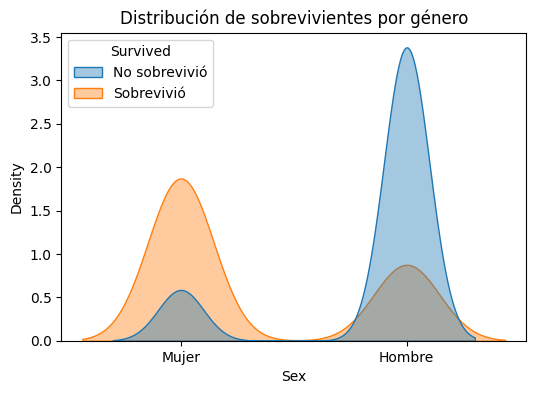

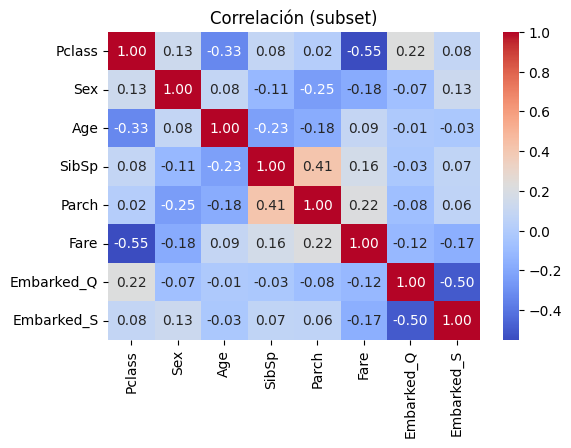

In [231]:
# Distribución por género
feat = "Sex"
y_labels = y.map({0: "No sobrevivió", 1: "Sobrevivió"})
plt.figure(figsize=(6,4))
sns.kdeplot(x=X[feat], hue=y_labels, fill=True, common_norm=False, alpha=0.4)
plt.title(f"Distribución de sobrevivientes por género")
plt.xticks([0, 1], ["Mujer", "Hombre"])
plt.xlabel(feat)
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación (subset)")
plt.show()

In [232]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Pipeline: Estandarización + Regresión Logística (L2 por defecto)
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=500, solver="liblinear", class_weight=None))
])
pipe.fit(X_train, y_train)

# Coeficientes con nombres
coef = pipe.named_steps["logreg"].coef_.ravel()
coef_df = pd.DataFrame({"feature": X.columns, "coef": coef}).sort_values("coef", key=np.abs, ascending=False)
coef_df.head(10)


,feature,coef
1,Sex,-1.266342
0,Pclass,-0.928040
2,Age,-0.510949
3,SibSp,-0.262146
7,Embarked_S,-0.183480
5,Fare,0.097147
6,Embarked_Q,0.083974
4,Parch,-0.070444


Accuracy: 0.8044692737430168
               precision    recall  f1-score   support

    Fallecido       0.81      0.89      0.85       110
Sobreviviente       0.79      0.67      0.72        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179



/Users/hugo/repos/ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hugo/repos/ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hugo/repos/ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hugo/repos/ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hugo/repos/ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hugo/repos/ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


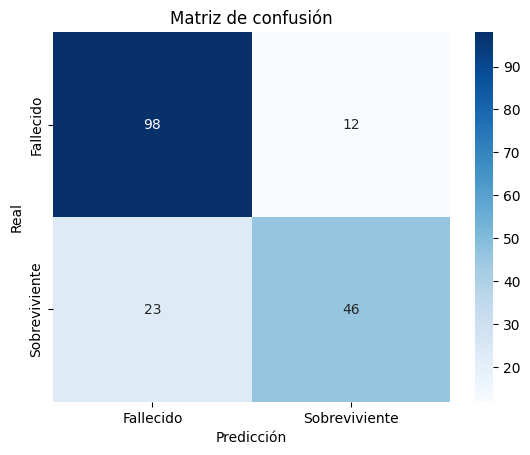

In [233]:
# Predicción y métricas
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

target_names = ['Fallecido', 'Sobreviviente']

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión")
plt.show()



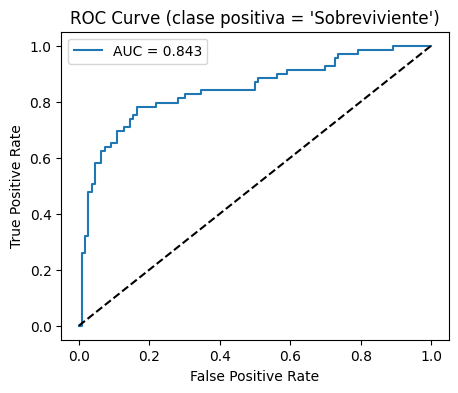

In [234]:
fpr, tpr, thr = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (clase positiva = 'Sobreviviente')")
plt.legend(); plt.show()

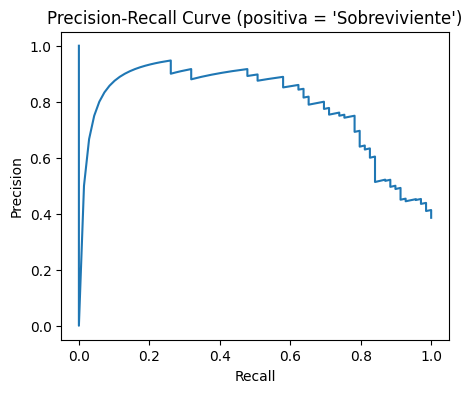

In [235]:
# Precisión-Recall
prec, rec, thr_pr = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(5,4))
plt.plot(rec, prec)
plt.xlabel("Recall");
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (positiva = 'Sobreviviente')")
plt.show()